In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Step 1: Define the ODE function
def f(x, y):
    return x**2 + 2*y  # dy/dx = x + y

# Step 2: Define initial conditions
x0 = 2     # starting x value
y0 = 1      # initial y value y(0) = 1
h = 0.1     # step size
n = 20      # number of steps

In [3]:
# Step 3: Initialize arrays to store results
x_vals = [x0]
y_vals = [y0]



In [4]:
# Step 4: Euler’s method loop
for i in range(n):
    x_next = x_vals[-1] + h
    y_next = y_vals[-1] + h * f(x_vals[-1], y_vals[-1])
    x_vals.append(x_next)
    y_vals.append(y_next)

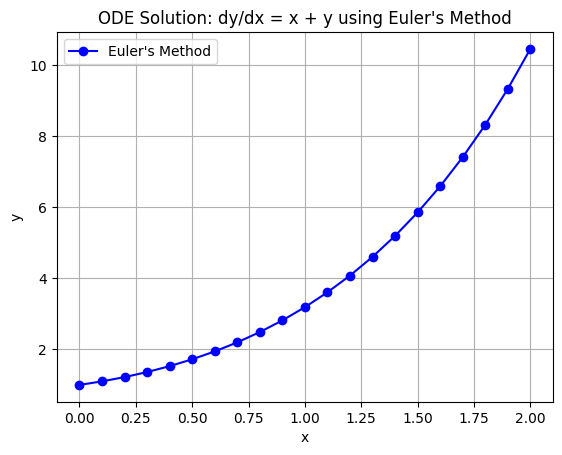

In [5]:


# Step 5: Plot the result
plt.plot(x_vals, y_vals, label="Euler's Method", color='blue', marker='o')
plt.title("ODE Solution: dy/dx = x + y using Euler's Method")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
# Parameters
L = 1.0          # Length of the rod
T = 0.5          # Total time
nx = 20          # Number of spatial points
nt = 1000        # Number of time steps
alpha = 0.01     # Diffusion coefficient
dx = L / (nx - 1)
dt = T / nt
r = alpha * dt / dx**2  # Stability parameter

In [7]:


# Initial and boundary conditions
u = np.zeros(nx)
u[int(0.4 * nx):int(0.6 * nx)] = 1.0  # Initial condition: small bump in center

# Save for plotting
u_record = [u.copy()]

In [8]:
# Time-stepping loop
for _ in range(nt):
    u_new = u.copy()
    for i in range(1, nx - 1):
        u_new[i] = u[i] + r * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new.copy()
    if _ % 200 == 0:
        u_record.append(u.copy())

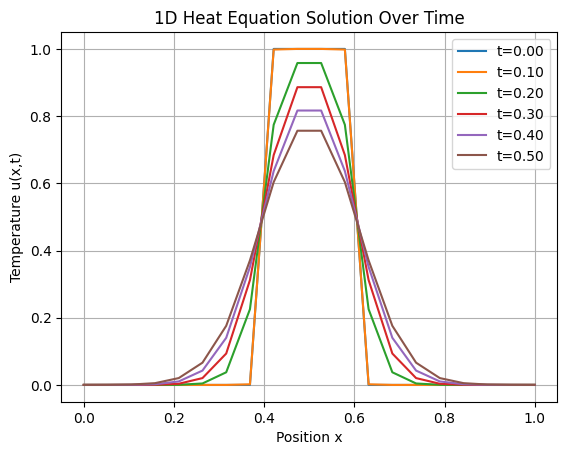

In [9]:
# Plot results
x = np.linspace(0, L, nx)
for i, u_plot in enumerate(u_record):
    plt.plot(x, u_plot, label=f't={i * dt * 200:.2f}')
plt.xlabel('Position x')
plt.ylabel('Temperature u(x,t)')
plt.title('1D Heat Equation Solution Over Time')
plt.legend()
plt.grid(True)
plt.show()
